In [1]:
# Import packages
import pandas as pd
import numpy as np

import ossify as osy
from standard_transform.datasets import v1dd_ds

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import sys
from os.path import join as pjoin
from typing import Optional, Union
utils_path = "/root/capsule/code/utils"
sys.path.insert(0, utils_path)

import itertools

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import tqdm
from connects_common_connectivity.io import DatasetReader, read_synapse_table
from matplotlib import pyplot as plt
from scipy import spatial, stats
from scipy.sparse import csr_array

from paths import resolve_data_root, resolve_dataset_dir


In [2]:
import os
from caveclient import CAVEclient

client = CAVEclient("v1dd_public", server_address="https://global.em.brain.allentech.org", auth_token=os.environ["API_SECRET"])


In [3]:
thal_syn = pd.read_csv('thal_syn.csv')

print("thal axons:", thal_syn["pre_pt_root_id"].nunique())
print("post root IDs:", thal_syn["post_pt_root_id"].nunique())
print("synapses:", len(thal_syn))

thal axons: 97
post root IDs: 321532
synapses: 463661


In [4]:
# merge the dataframe to label the cell type (E or I) of post-synaptice neurons
cell_types = client.materialize.query_table(
    "cell_type_multifeature_v1",
)

print(cell_types.columns)
cell_types[[
    "pt_root_id",
    "classification_system",
    "cell_type"
]].head()

ct = cell_types[
    ["pt_root_id", "classification_system", "cell_type"]
].drop_duplicates("pt_root_id")

thal_typed = thal_syn.merge(
    ct,
    left_on="post_pt_root_id",
    right_on="pt_root_id",
    how="inner"
)

# dividing thal_syn into T->E and T -> I
T_E_syn = thal_typed[
    thal_typed["classification_system"] == "excitatory"
].copy()

T_I_syn = thal_typed[
    thal_typed["classification_system"] == "inhibitory"
].copy()

Index(['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_supervoxel_id',
       'pt_root_id', 'id', 'created', 'valid', 'target_id',
       'classification_system', 'cell_type', 'pt_position',
       'bb_start_position', 'bb_end_position'],
      dtype='object')


In [ ]:
# W_TE: thalamocortical axon × E neuron
TE = (
    T_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)

W_TE = TE.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

TE_size = (
    T_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("size")
    .reset_index()
)

W_TE_size = TE_size.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="size"
).fillna(0)


In [35]:
TE

post_pt_root_id,864691132533275738,864691132533347418,864691132533614170,864691132533617242,864691132533621850,864691132533623130,864691132533624410,864691132533626458,864691132533627482,864691132533631066,...,864691133313636944,864691133313665616,864691133313949520,864691133314022736,864691133314112336,864691133314166096,864691133314201424,864691133314213712,864691133314222928,864691133314231632
pre_pt_root_id,,,,,,,,,,,,,,,,,,,,,
864691132537321562,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0
864691132549572162,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0
864691132572564252,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,1.0,0.0,0.0,0.0,0,0.0,0.0
864691132582739474,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0
864691132582742802,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864691132970239597,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0
864691133001102261,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0.0,0.0
864691133050913636,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0.0,0.0,0.0,0.0,0,1.0,0.0


In [6]:
# W_TI
TI = (
    T_I_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)


thal_recipient_I = TI["post_pt_root_id"].unique()

thal_recipient_I

array([864691132561636836, 864691132563533028, 864691132574637882, ...,
       864691132984526432, 864691133064998216, 864691133068459977],
      shape=(2752,))

In [9]:
proof = client.materialize.query_table(
    "proofreading_status_and_strategy",
    materialization_version=1196
)

proof_I = proof[
    (proof["status_axon"] == True) &
    (proof["pt_root_id"].isin(thal_recipient_I))
].copy()

I_ids = [
    int(x)
    for x in proof_I["pt_root_id"].dropna().unique()
]

len(I_ids)

I_syn = pd.read_csv('I_syn.csv')

In [10]:
#i'm interested in those with synaptic target = E
I_syn_typed = I_syn.merge(
    ct,
    left_on="post_pt_root_id",
    right_on="pt_root_id",
    how="inner"
)

I_E_syn = I_syn_typed[
    I_syn_typed["classification_system"] == "excitatory"
].copy()

In [11]:
W_TI = TI.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

IE = (
    I_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)

W_IE = IE.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

In [ ]:
common_I = W_TI.columns.intersection(W_IE.index)

W_TI2 = W_TI.loc[:, common_I] # thalamocortical axon × I neuron
W_IE2 = W_IE.loc[common_I, :] # I neuron × E neuron

A = (W_TI2 > 0).astype(int)
B = (W_IE2 > 0).astype(int)

FFI_paths = A @ B

In [13]:
common_T = W_TE.index.intersection(FFI_paths.index)
common_E = W_TE.columns.intersection(FFI_paths.columns)

Direct = W_TE.loc[common_T, common_E] # direct excitation

FFI = FFI_paths.loc[common_T, common_E] # feedforward inhibition

In [14]:
# same thalamic axons
common_T = W_TE.index.intersection(W_TI2.index)

TE = W_TE.loc[common_T].copy()
TI = W_TI2.loc[common_T].copy()

# same inhibitory neurons
common_I = TI.columns.intersection(W_IE2.index)

TI = TI.loc[:, common_I]
IE = W_IE2.loc[common_I, :].copy()

# E neurons appearing in either direct or inhibitory pathway
all_E = TE.columns.union(IE.columns)

TE = TE.reindex(columns=all_E, fill_value=0)
IE = IE.reindex(columns=all_E, fill_value=0)

print(TE.shape)   # T × E
print(TI.shape)   # T × I
print(IE.shape)   # I × E

(97, 28542)
(97, 415)
(415, 28542)


## Total number of direct T→E synapses

$D_i = \Sigma_{t} W_{TE}(t,j)$

In [ ]:

direct_synapses = TE.sum(axis=0)

# Number of distinct thalamic axons contacting each E
n_thal_sources = (TE > 0).sum(axis=0)


# Average synapses per connected thalamic axon
direct_syn_per_source = (
    direct_synapses /
    n_thal_sources.replace(0, np.nan)
)

In [34]:
direct_synapses

post_pt_root_id
864691132533275738     4.0
864691132533347418    18.0
864691132533614170     6.0
864691132533617242     0.0
864691132533621850     2.0
                      ... 
864691133314166096    14.0
864691133314201424     1.0
864691133314213712     0.0
864691133314222928     4.0
864691133314231632    13.0
Length: 28542, dtype: float64

## Direct input concentration

Looking at the distribution of inputs; have many inputs with weak weights or have strong few input?

In [37]:
P_source = TE.div(
    TE.sum(axis=0).replace(0, np.nan),
    axis=1
).fillna(0)

direct_concentration = (P_source ** 2).sum(axis=0)

# 1 に近い → 1本または少数の thalamic axon に集中
# 小さい → 多数の thalamic axon に分散

In [ ]:
# effective nunmber of thalamic sources

effective_n_thal_sources = (
    1 / direct_concentration.replace(0, np.nan)
)



## FFI structural features

In [39]:
TI_binary = (TI > 0).astype(int)
IE_binary = (IE > 0).astype(int)

FFI_paths = TI_binary @ IE_binary

# How many thalamically innervated inhibitory neurons converge onto this E neuron?
# NOT THE SYNAPSE COUNT
ffi_path_count = FFI_paths.sum(axis=0)

## Weighted FFI score

In [40]:
thal_driven_I = (TI > 0).any(axis=0)

ffi_I = IE.loc[thal_driven_I]

n_ffi_interneurons = (ffi_I > 0).sum(axis=0)

In [ ]:
thal_drive_to_I = TI.sum(axis=0)

ffi_weighted = (
    IE.mul(thal_drive_to_I, axis=0)
    .sum(axis=0)
) #synapse count * synapse count

## normalized routing

In [22]:
T_output = (
    TE.sum(axis=1) +
    TI.sum(axis=1)
).replace(0, np.nan)

P_TE = TE.div(T_output, axis=0).fillna(0)
P_TI = TI.div(T_output, axis=0).fillna(0)

In [23]:
I_output_to_E = IE.sum(axis=1).replace(0, np.nan)

P_IE = IE.div(
    I_output_to_E,
    axis=0
).fillna(0)

In [24]:
R_FFI = P_TI @ P_IE
R_direct = P_TE

direct_routing = R_direct.sum(axis=0)
ffi_routing = R_FFI.sum(axis=0)

eps = 1e-12

routing_balance = (
    (direct_routing - ffi_routing)
    /
    (direct_routing + ffi_routing + eps)
)

routing_engagement = (
    direct_routing + ffi_routing
)

In [25]:
structural_features = pd.DataFrame({
    "pt_root_id": all_E,

    # Direct
    "direct_synapses": direct_synapses.reindex(all_E, fill_value=0).values,
    "n_thal_sources": n_thal_sources.reindex(all_E, fill_value=0).values,
    "direct_syn_per_source": direct_syn_per_source.reindex(all_E).values,
    "direct_concentration": direct_concentration.reindex(all_E, fill_value=0).values,
    "effective_n_thal_sources": effective_n_thal_sources.reindex(all_E).values,

    # FFI
    "ffi_path_count": ffi_path_count.reindex(all_E, fill_value=0).values,
    "n_ffi_interneurons": n_ffi_interneurons.reindex(all_E, fill_value=0).values,
    "ffi_weighted": ffi_weighted.reindex(all_E, fill_value=0).values,

    # normalized Direct/FFI axis
    "direct_routing": direct_routing.reindex(all_E, fill_value=0).values,
    "ffi_routing": ffi_routing.reindex(all_E, fill_value=0).values,
    "routing_balance": routing_balance.reindex(all_E, fill_value=0).values,
    "routing_engagement": routing_engagement.reindex(all_E, fill_value=0).values,
})

In [31]:
E_meta = (
    cell_types[
        cell_types["classification_system"] == "excitatory"
    ][
        ["pt_root_id", "cell_type"]
    ]
    .drop_duplicates("pt_root_id")
    .copy()
)

E_meta["layer"] = (
    E_meta["cell_type"]
    .str.extract(r"^(L[2-6])")
)

In [32]:
structural_features = structural_features.merge(
    E_meta[
        ["pt_root_id", "cell_type", "layer"]
    ].drop_duplicates("pt_root_id"),
    on="pt_root_id",
    how="left"
)

In [33]:
structural_features.head()

,pt_root_id,direct_synapses,n_thal_sources,direct_syn_per_source,direct_concentration,effective_n_thal_sources,ffi_path_count,n_ffi_interneurons,ffi_weighted,direct_routing,ffi_routing,routing_balance,routing_engagement,cell_type,layer
0,864691132533275738,4.0,3,1.333333,0.375000,2.666667,122,10,284.0,0.002988,5.614796e-05,0.963108,3.043910e-03,L4IT,L4
1,864691132533347418,18.0,11,1.636364,0.104938,9.529412,1058,44,5057.0,0.019732,1.828389e-03,0.830393,2.156030e-02,L4IT,L4
2,864691132533614170,6.0,5,1.200000,0.222222,4.500000,52,4,74.0,0.004416,1.574575e-05,0.992894,4.431555e-03,L4IT,L4
3,864691132533617242,0.0,0,NaN,0.000000,NaN,5,1,5.0,0.000000,9.732057e-07,-0.999999,9.732057e-07,L6CT,L6
4,864691132533621850,2.0,1,2.000000,1.000000,1.000000,0,0,0.0,0.001869,0.000000e+00,1.000000,1.869159e-03,L2IT,L2


## Plotting

In [41]:
feature_cols = [
    "direct_synapses",
    "n_thal_sources",
    "direct_concentration",
    "ffi_path_count",
    "n_ffi_interneurons",
    "ffi_weighted",
    "direct_routing",
    "ffi_routing",
    "routing_balance",
    "routing_engagement",
]

In [42]:
structural_features[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
direct_synapses,28542.0,2.986126,4.623017,0.000000e+00,0.000000,1.000000,4.000000,41.000000
n_thal_sources,28542.0,2.447551,3.518480,0.000000e+00,0.000000,1.000000,3.000000,26.000000
direct_concentration,28542.0,0.316832,0.376669,0.000000e+00,0.000000,0.159763,0.500000,1.000000
ffi_path_count,28542.0,204.403931,309.906928,0.000000e+00,11.000000,58.000000,260.000000,2522.000000
n_ffi_interneurons,28542.0,15.597891,19.999530,0.000000e+00,2.000000,7.000000,22.000000,165.000000
ffi_weighted,28542.0,792.748091,1489.287494,0.000000e+00,17.000000,120.000000,777.000000,17896.000000
direct_routing,28542.0,0.003078,0.005198,0.000000e+00,0.000000,0.000934,0.003937,0.089282
ffi_routing,28542.0,0.000320,0.000607,0.000000e+00,0.000007,0.000052,0.000344,0.010225
routing_balance,28542.0,0.120599,0.909414,-1.000000e+00,-1.000000,0.726803,0.924326,1.000000
routing_engagement,28542.0,0.003399,0.005630,1.566846e-07,0.000022,0.001067,0.004306,0.091509


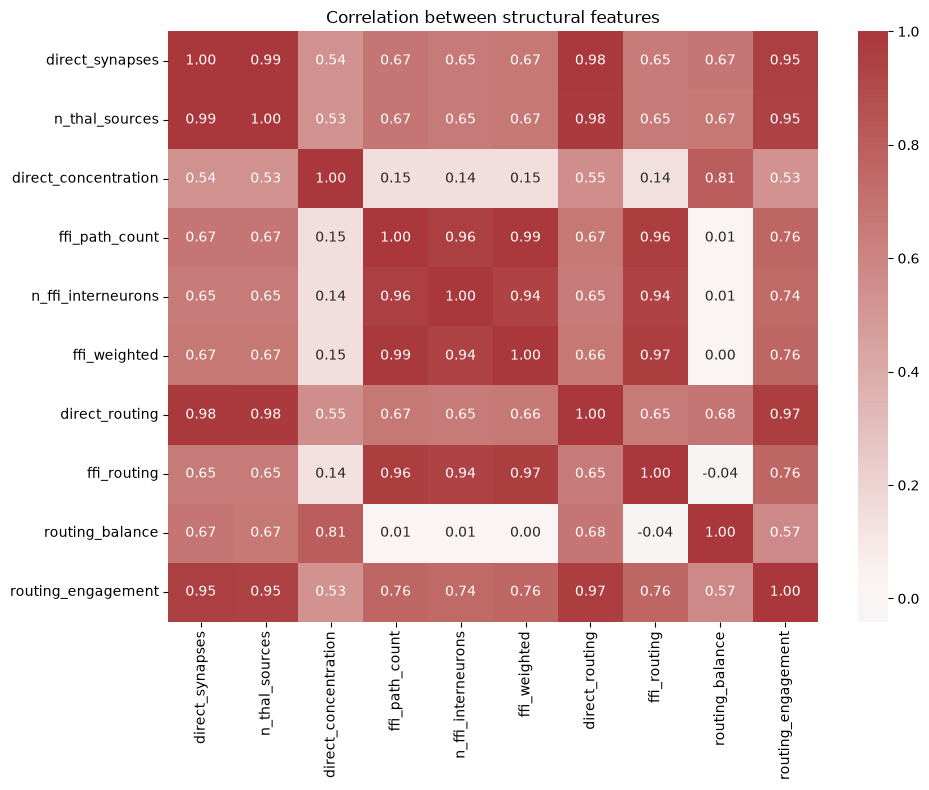

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_features = structural_features[feature_cols].copy()

log_features = [
    "direct_synapses",
    "n_thal_sources",
    "ffi_path_count",
    "n_ffi_interneurons",
    "ffi_weighted",
    "direct_routing",
    "ffi_routing",
    "routing_engagement",
]

for col in log_features:
    plot_features[col] = np.log1p(plot_features[col])

corr = plot_features.corr(method="spearman")

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("Correlation between structural features")
plt.tight_layout()
plt.show()

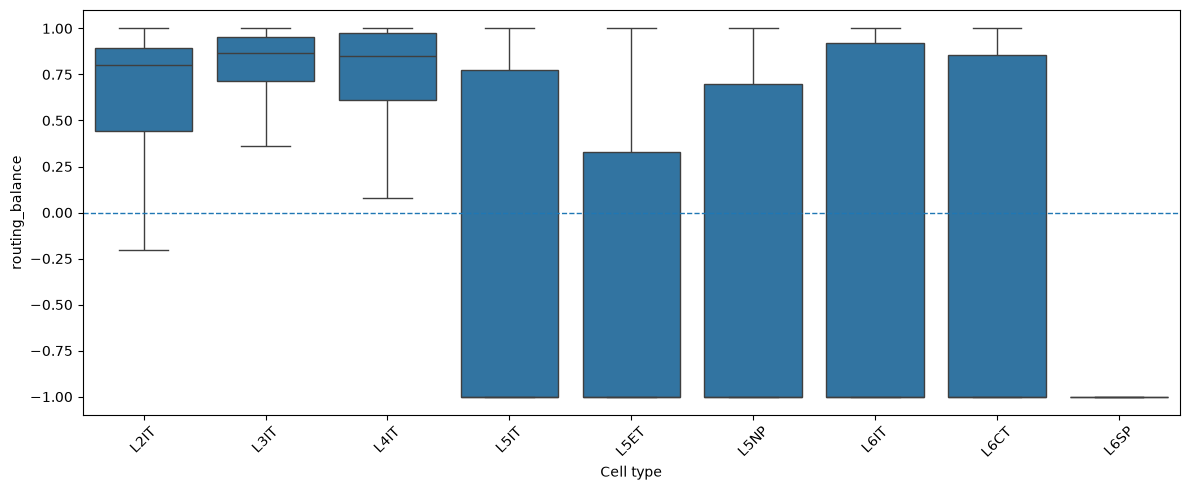

In [54]:
main_features = [
    "direct_synapses",
    "n_ffi_interneurons",
    "routing_balance",
    "direct_concentration",
]

plot_df = structural_features[
    ["pt_root_id", "cell_type"] + main_features
].copy()

plot_df["log_direct_synapses"] = np.log1p(
    plot_df["direct_synapses"]
)

plot_df["log_n_ffi_interneurons"] = np.log1p(
    plot_df["n_ffi_interneurons"]
)

celltype_order = [
    "L2IT",
    "L3IT",
    "L4IT",
    "L5IT",
    "L5ET",
    "L5NP",
    "L6IT",
    "L6CT",
    "L6SP",
]

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=plot_df,
    x="cell_type",
    y="routing_balance",
    order=celltype_order,
    showfliers=False
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Cell type")
plt.ylabel("routing_balance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

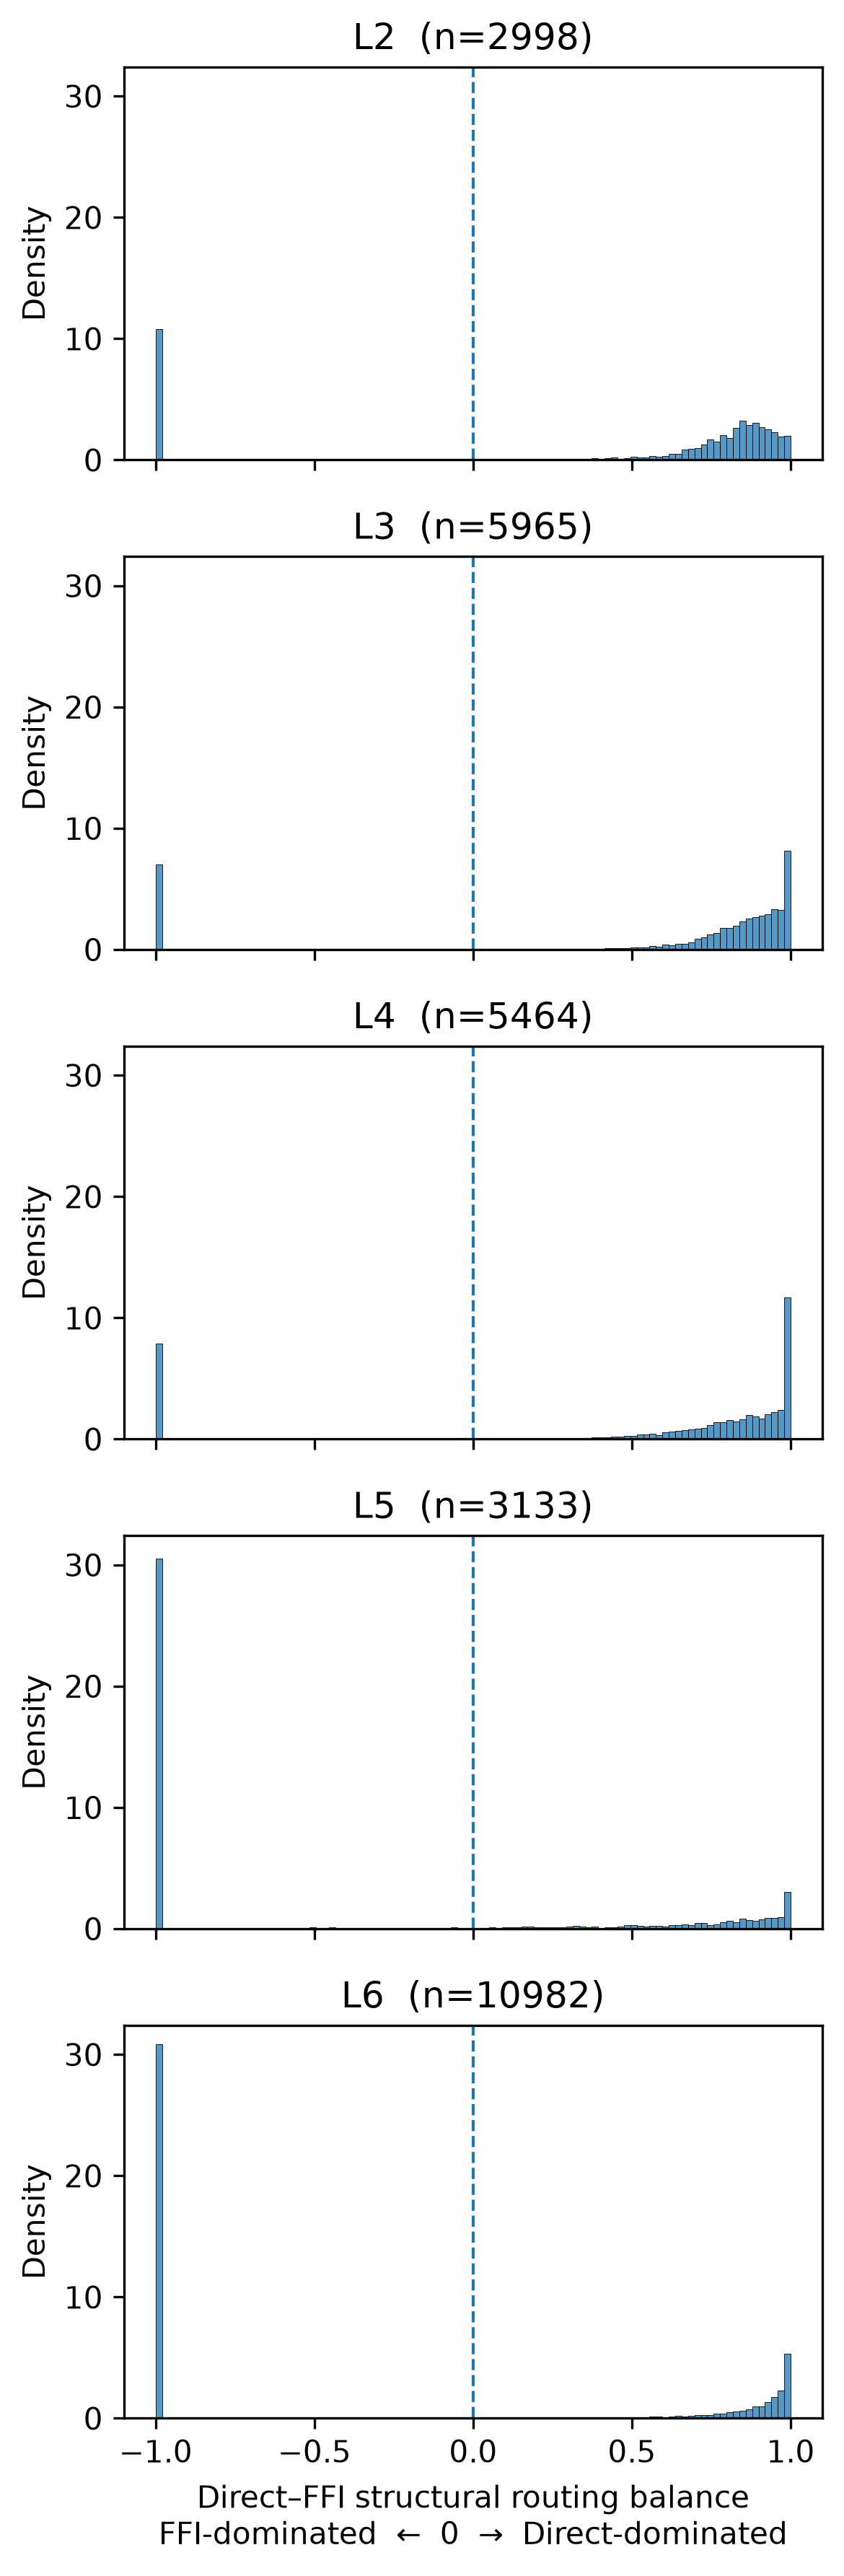

In [58]:
plot_df = structural_features[
    ["pt_root_id", "layer", "routing_balance"]
].dropna()

layer_order = ["L2", "L3", "L4", "L5", "L6"]

bins = np.linspace(-1, 1, 100)

fig, axes = plt.subplots(
    5, 1,
    figsize=(4, 12), dpi = 300,
    sharex=True,
    sharey=True
)

for ax, layer in zip(axes, layer_order):

    sub = plot_df[plot_df["layer"] == layer]

    sns.histplot(
        data=sub,
        x="routing_balance",
        bins=bins,
        stat="density",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{layer}  (n={len(sub)})")
    ax.set_ylabel("Density")

axes[-1].set_xlabel(
    "Direct–FFI structural routing balance\n"
    "FFI-dominated  ←  0  →  Direct-dominated"
)

plt.tight_layout()
plt.show()